# Analyse Exploratoire des Donnees - Score Lieux Culturels

## Objectif
Analyse complete des lieux, equipements et activites culturelles en Ile-de-France et a Paris pour construire un indicateur `score_lieu_culture`.

## Sources de donnees
- parisdata.opendatasoft.com / opendata.paris.fr
- data.iledefrance.fr
- data.gouv.fr (via MCP pour BPE sport/culture)


## 1. Configuration et Imports

In [1]:
# Import des bibliotheques standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import requests
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print('Configuration completee avec succes')
print(f'Version pandas: {pd.__version__}')
print(f'Version numpy: {np.__version__}')
print(f"Date d'analyse: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


Configuration completee avec succes
Version pandas: 2.2.3
Version numpy: 2.2.3
Date d'analyse: 2026-05-22 15:25:16


## 2. Fonctions Utilitaires pour les APIs

Fonctions pour interroger OpenDataSoft (Paris Data et Data Ile-de-France) et preparer les donnees retournees par API.

In [2]:
def fetch_opendatasoft_data(base_url, dataset_id, rows=10000):
    """
    Recupere les donnees d'un dataset OpenDataSoft.
    Meme approche que les notebooks services publics et transport.
    """
    all_records = []
    start = 0
    batch_size = 100
    print(f'Recuperation des donnees de {dataset_id}...')

    while True:
        api_url = f'{base_url}/api/records/1.0/search/'
        params = {'dataset': dataset_id, 'rows': batch_size, 'start': start}
        try:
            response = requests.get(api_url, params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
            records = data.get('records', [])
            if not records:
                break
            for record in records:
                all_records.append(record.get('fields', {}))
            start += batch_size
            total_count = data.get('nhits', 0)
            if start >= total_count or start >= rows:
                break
        except Exception as e:
            print(f'Erreur lors de la recuperation: {e}')
            break

    df = pd.DataFrame(all_records)
    print(f'Dataset {dataset_id}: {len(df)} enregistrements recuperes')
    return df


def safe_fetch_opendatasoft_data(base_url, dataset_id, rows=10000):
    """Tente plusieurs domaines OpenDataSoft compatibles avec les jeux Paris."""
    candidates = [base_url]
    if 'parisdata.opendatasoft.com' not in candidates:
        candidates.append('https://parisdata.opendatasoft.com')
    if 'opendata.paris.fr' not in candidates:
        candidates.append('https://opendata.paris.fr')

    for candidate in candidates:
        df = fetch_opendatasoft_data(candidate, dataset_id, rows=rows)
        if not df.empty:
            return df
    return pd.DataFrame()


def print_dataset_preview(name, df):
    print(f"\n--- Apercu des donnees {name} ---")
    print(f"Shape: {df.shape}")
    print("\nColonnes disponibles:")
    print(df.columns.tolist())
    print("\nPremiers enregistrements:")
    display(df.head())
    if len(df) > 0:
        print("\nTypes de donnees:")
        print(df.dtypes)

print('Fonctions utilitaires chargees avec succes')


Fonctions utilitaires chargees avec succes


## 3. Chargement des Donnees Culturelles via API

### 3.1 Lieux de tournage a Paris

In [3]:
df_tournages = safe_fetch_opendatasoft_data(
    base_url='https://parisdata.opendatasoft.com',
    dataset_id='lieux-de-tournage-a-paris',
    rows=20000
)
print_dataset_preview('Lieux de tournage', df_tournages)


Recuperation des donnees de lieux-de-tournage-a-paris...
Erreur lors de la recuperation: 400 Client Error: Bad Request for url: https://parisdata.opendatasoft.com/api/records/1.0/search/?dataset=lieux-de-tournage-a-paris&rows=100&start=10000
Dataset lieux-de-tournage-a-paris: 10000 enregistrements recuperes

--- Apercu des donnees Lieux de tournage ---
Shape: (10000, 14)

Colonnes disponibles:
['coord_x', 'id_lieu', 'adresse_lieu', 'geo_shape', 'coord_y', 'ardt_lieu', 'nom_tournage', 'nom_realisateur', 'date_debut', 'type_tournage', 'annee_tournage', 'nom_producteur', 'date_fin', 'geo_point_2d']

Premiers enregistrements:


,coord_x,id_lieu,adresse_lieu,geo_shape,coord_y,ardt_lieu,nom_tournage,nom_realisateur,date_debut,type_tournage,annee_tournage,nom_producteur,date_fin,geo_point_2d
0,2.294570,2016-1939,AVENUE DU PRESIDENT WILSON,"{'coordinates': [2.294570000235056, 48.8646140...",48.864614,75016,LES HOMMES DE L'OMBRE,FRED GARSON,2016-02-13,Série TV,2016,MACONDO,2016-02-13,"[48.864614000274074, 2.294570000235056]"
1,2.355564,2016-1495,PLACE D'ITALIE,"{'coordinates': [2.355563999715622, 48.8322939...",48.832294,75013,MAMAN A TORT,MARC FITOUSSI,2016-01-06,Long métrage,2016,AVENUE B,2016-01-06,"[48.83229399959034, 2.355563999715622]"
2,2.350066,2020-1082,"rue buot, 75013 paris","{'coordinates': [2.3500655715034946, 48.826578...",48.826579,75013,STELLA EST AMOUREUSE,Sylvie Verheyde,2020-12-22,Long métrage,2020,ATELIER DE PRODUCTION,2020-12-22,"[48.82657866735516, 2.3500655715034946]"
3,2.354527,2016-2623,BOULEVARD DE DENAIN,"{'coordinates': [2.354527000351158, 48.8793910...",48.879391,75010,THE ESCAPE,DOMINIC SAVAGE,2016-10-19,Long métrage,2016,HANNA FILMS,2016-10-19,"[48.87939100020501, 2.354527000351158]"
4,2.387530,2019-878,"15 rue jacques hillairet, 75012 paris","{'coordinates': [2.3875303963761287, 48.842766...",48.842767,75012,PARENT D'ELEVE,NOEMIE SAGLIO,2019-07-16,Long métrage,2019,RECTANGLE PRODUCTIONS,2019-07-16,"[48.842766930345334, 2.3875303963761287]"



Types de donnees:
coord_x            float64
id_lieu             object
adresse_lieu        object
geo_shape           object
coord_y            float64
ardt_lieu           object
nom_tournage        object
nom_realisateur     object
date_debut          object
type_tournage       object
annee_tournage      object
nom_producteur      object
date_fin            object
geo_point_2d        object
dtype: object


### 3.2 Evenements et activites - Que Faire a Paris

In [4]:
df_qfap = safe_fetch_opendatasoft_data(
    base_url='https://opendata.paris.fr',
    dataset_id='que-faire-a-paris-',
    rows=20000
)
print_dataset_preview('Que Faire a Paris', df_qfap)


Recuperation des donnees de que-faire-a-paris-...
Dataset que-faire-a-paris-: 3437 enregistrements recuperes

--- Apercu des donnees Que Faire a Paris ---
Shape: (3437, 60)

Colonnes disponibles:
['lat_lon', 'title', 'lead_text', 'event_id', 'access_type', 'occurrences', 'event_indoor', 'price_type', 'weight', 'title_event', 'address_city', 'cover_alt', 'deaf', 'group', 'qfap_tags', 'access_link', 'audience', 'description', 'date_start', 'address_street', 'access_link_text', 'pmr', 'rank', 'date_end', 'event_pets_allowed', 'mental', 'address_zipcode', 'locale', 'cover_credit', 'price_detail', 'cover_url', 'url', 'blind', 'id', 'date_description', 'updated_at', 'address_name', 'locations', 'sign_language', 'contact_instagram', 'childrens', 'contact_organisation_name', 'contact_phone', 'contact_facebook', 'contact_mail', 'contact_url', 'contact_url_text', 'programs', 'transport', 'contact_youtube', 'contact_linkedin', 'address_text', 'contact_twitter', 'univers', 'universe_tags', 'addres

,lat_lon,title,lead_text,event_id,access_type,occurrences,event_indoor,price_type,weight,title_event,address_city,cover_alt,deaf,group,qfap_tags,access_link,audience,description,date_start,address_street,access_link_text,pmr,rank,date_end,event_pets_allowed,mental,address_zipcode,locale,cover_credit,price_detail,cover_url,url,blind,id,date_description,updated_at,address_name,locations,sign_language,contact_instagram,childrens,contact_organisation_name,contact_phone,contact_facebook,contact_mail,contact_url,contact_url_text,programs,transport,contact_youtube,contact_linkedin,address_text,contact_twitter,univers,universe_tags,address_url,address_url_text,contact_soundcloud,contact_vimeo,contact_pinterest
0,"[48.8659644390434, 2.29644276066476]","On a adoré l’expo « Tisser, broder, sublimer. ...",Il ne fallait pas moins de trois volets pour r...,77805,obligatoire,2025-12-13T10:00:00+02:00_2025-12-13T18:00:00+...,1,payant,2.0,"Tisser, broder, sublimer. Les savoir-faire de ...",Paris,Comme des Garçons AH 2016-2017,1.0,Aucun,Expo,https://www.palaisgalliera.paris.fr/exposition...,Tout public.,<p>Cette première expo est consacrée aux\nsavo...,2025-12-13T10:00:00+00:00,10 avenue Pierre 1er de Serbie,Plus d’infos,1.0,814.69,2026-10-18T19:00:00+00:00,0,1,75016,fr,Palais Galliera / Paris Musées,<p>De 0 à 14 euros.</p>,https://cdn.paris.fr/qfapv4/2026/01/09/huge-cf...,https://www.paris.fr/evenements/tisser-broder-...,1.0,104035,Du samedi 13 décembre 2025 au dimanche 18 octo...,2026-02-06T15:28:56+00:00,Palais Galliera - musée de la Mode de Paris,[{'address_street': '10 avenue Pierre 1er de S...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[48.851503, 2.351091]",Tribute to Brandford Marsalis,C'est au sein de son formidable quartet que Sé...,79672,obligatoire,2026-10-23T20:00:00+02:00_2026-10-23T22:00:00+...,1,payant,1.0,Tribute to Brandford Marsalis,Paris 05,Tribute to Brandford Marsalis,NaN,Aucun,Concert;Festival,https://www.sondelaterre.fr/event/tribute-to-b...,Tout public.,"<p>Depuis toujours, Sébastien Jarrousse a été ...",2026-10-23T21:00:00+00:00,2 Port de Montebello,Billetterie,NaN,311.09,2026-10-23T23:00:00+00:00,0,NaN,75005,fr,NaN,Billetterie : 25 EUR,https://cdn.paris.fr/qfapv4/2026/02/09/huge-e6...,https://www.paris.fr/evenements/tribute-to-bra...,NaN,105956,Le vendredi 23 octobre 2026<br />de 20h00 à 22...,2026-02-09T09:12:16+00:00,Le Son de la Terre,"[{'accessibility': {'blind': None, 'pmr': None...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[48.8521710079406, 2.27478699864577]",Agenda artistique du Conservatoire Municipal F...,Le Conservatoire Muncipal du 16ème vous propos...,80092,non,NaN,1,gratuit,1.0,NaN,Paris,Conservatoire Francis Poulenc,0.0,Conservatoires,Concert;Danse;Théâtre,NaN,Tout public.,"<p>Sur cette page, vous trouverez les principa...",2025-09-15T00:00:00+00:00,"11, rue Jean de la Fontaine",NaN,1.0,814.69,2026-06-27T23:59:59+00:00,0,1,75016,fr,Conservatoire Francis Poulenc,NaN,https://cdn.paris.fr/qfapv4/2026/02/17/huge-25...,https://www.paris.fr/evenements/agenda-artisti...,NaN,106408,Du lundi 15 septembre 2025 au samedi 27 juin 2...,2026-02-17T11:10:30+00:00,Conservatoire Municipal Francis Poulenc,"[{'address_street': '11, rue Jean de la Fontai...",0,https://www.instagram.com/conservatoire_paris16/,L'Histoire du soldat (https://www.paris.fr/eve...,Conservatoire Municipal Francis Poulenc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[48.870474989, 2.40313899815229]",Personne ne sait que je suis là,"À l’aube, Marthe et Sofia se rencontrent à que...",80118,obligatoire,2026-05-22T20:00:00+02:00_2026-05-22T21:00:00+...,1,payant,1.0,Festival ZOOM #11,Paris,NaN,NaN,Agenda,Théâtre,https://theatre-ouvert.mapado.com/event/670482...,Public adultes. A partir de 13 ans.,"<p>Une alarme retentit, les certitudes se renf...",2026-05-22T21:00:00+00:00,159 Avenue Gambetta,NaN,1.0,3872.98,2026-05-22T22:00:0


Types de donnees:
lat_lon                       object
title                         object
lead_text                     object
event_id                       int64
access_type                   object
occurrences                   object
event_indoor                   int64
price_type                    object
weight                       float64
title_event                   object
address_city                  object
cover_alt                     object
deaf                         float64
group                         object
qfap_tags                     object
access_link                   object
audience                      object
description                   object
date_start                    object
address_street                object
access_link_text              object
pmr                          float64
rank                         float64
date_end                      object
event_pets_allowed             int64
mental                        object
address_zipcode    

### 3.3 Terrasses et etalages autorises

In [5]:
df_terrasses = safe_fetch_opendatasoft_data(
    base_url='https://opendata.paris.fr',
    dataset_id='terrasses-autorisations',
    rows=30000
)
print_dataset_preview('Terrasses autorisees', df_terrasses)


Recuperation des donnees de terrasses-autorisations...
Erreur lors de la recuperation: 400 Client Error: Bad Request for url: https://opendata.paris.fr/api/records/1.0/search/?dataset=terrasses-autorisations&rows=100&start=10000
Dataset terrasses-autorisations: 10000 enregistrements recuperes

--- Apercu des donnees Terrasses autorisees ---
Shape: (10000, 12)

Colonnes disponibles:
['largeur', 'typologie', 'nom_enseigne', 'geo_point_2d', 'lien_affichette', 'geo_shape', 'siret', 'arrondissement', 'adresse', 'longueur', 'nom_societe', 'periode_installation']

Premiers enregistrements:


,largeur,typologie,nom_enseigne,geo_point_2d,lien_affichette,geo_shape,siret,arrondissement,adresse,longueur,nom_societe,periode_installation
0,1.5,CONTRE TERRASSE SUR TROTTOIR,LE SALON,"[48.87047186137721, 2.3426190116656174]",https://eudonet-terrasses.apps.paris.fr/xrm/at...,"{'coordinates': [2.3426190116656174, 48.870471...",82162890600017,75002,151 RUE MONTMARTRE,2.00,NaN,NaN
1,2.6,TERRASSES OUVERTES SUR TROTTOIR,NONNA MIA,"[48.84968520754762, 2.3496330112690624]",NaN,"{'coordinates': [2.3496330112690624, 48.849685...",98807210400017,75005,47 BOULEVARD SAINT-GERMAIN,6.25,NaN,NaN
2,1.7,CONTRE TERRASSE ESTIVALE SUR STATIONNEMENT,PANGO,"[48.82943782114471, 2.379304912674614]",https://eudonet-terrasses.apps.paris.fr/xrm/at...,"{'coordinates': [2.379304912674614, 48.8294378...",93319066200025,NaN,31 RUE MARIE-ANDRÉE LAGROUA WEILL-HALLÉ,12.00,NaN,NaN
3,4.0,CONTRE TERRASSE ESTIVALE SUR PLACES ET TERRE-P...,142 CREPERIE CONTEMPORAINE,"[48.84886847962873, 2.2876439478692014]",NaN,"{'coordinates': [2.2876439478692014, 48.848868...",49471553500014,75015,59 PLACE SAINT CHARLES,7.80,NaN,NaN
4,1.5,CONTRE TERRASSE ESTIVALE SUR STATIONNEMENT,PRINCESSE CAFÉ,"[48.871183105043, 2.3682989680658313]",NaN,"{'coordinates': [2.3682989680658313, 48.871183...",88152371600028,75010,32 RUE BICHAT,5.70,NaN,NaN



Types de donnees:
largeur                 float64
typologie                object
nom_enseigne             object
geo_point_2d             object
lien_affichette          object
geo_shape                object
siret                    object
arrondissement           object
adresse                  object
longueur                float64
nom_societe              object
periode_installation     object
dtype: object


### 3.4 Salles de cinema en Ile-de-France

In [11]:
df_cinemas = fetch_opendatasoft_data(
    base_url='https://data.iledefrance.fr',
    dataset_id='les_salles_de_cinemas_en_ile-de-france',
    rows=10000
)
print_dataset_preview('Salles de cinema IDF', df_cinemas)


Recuperation des donnees de les_salles_de_cinemas_en_ile-de-france...
Dataset les_salles_de_cinemas_en_ile-de-france: 310 enregistrements recuperes

--- Apercu des donnees Salles de cinema IDF ---
Shape: (310, 37)

Colonnes disponibles:
['seances_2020', 'entrees_2020', 'pdm_en_entrees_des_films_francais_2020', 'population_de_la_commune_2015', 'pdm_en_entrees_des_films_europeens_2020', 'nombre_de_films_programmes_2020', 'pdm_en_entrees_des_autres_films_2020', 'nombre_de_films_en_semaine_1_2020', 'tranche_d_entrees', 'ndeg_auto', 'adresse', 'ecrans', 'evolution_entrees_2020_2019', 'multiplexe', 'nom', 'code_insee', 'unite_urbaine_2010', 'semaines_d_activite_2020', 'films_art_et_essai_2020', 'pdm_en_entrees_des_films_americains_2020', 'population_unite_urbaine_2015', 'situation_geographique', 'proprietaire', 'nombre_de_films_inedits_2020', 'part_des_seances_de_films_art_et_essai_2020', 'commune', 'dep', 'region_administrative', 'fauteuils', 'entrees_2019', 'art_et_essai', 'categorie_art_e

,seances_2020,entrees_2020,pdm_en_entrees_des_films_francais_2020,population_de_la_commune_2015,pdm_en_entrees_des_films_europeens_2020,nombre_de_films_programmes_2020,pdm_en_entrees_des_autres_films_2020,nombre_de_films_en_semaine_1_2020,tranche_d_entrees,ndeg_auto,adresse,ecrans,evolution_entrees_2020_2019,multiplexe,nom,code_insee,unite_urbaine_2010,semaines_d_activite_2020,films_art_et_essai_2020,pdm_en_entrees_des_films_americains_2020,population_unite_urbaine_2015,situation_geographique,proprietaire,nombre_de_films_inedits_2020,part_des_seances_de_films_art_et_essai_2020,commune,dep,region_administrative,fauteuils,entrees_2019,art_et_essai,categorie_art_et_essai,genre,geo,pdm_en_entrees_des_films_art_et_essai_2020,programmateur,label_art_et_essai
0,301.0,4737.0,60.760234,22154.0,5.701754,82.0,1.242690,0.0,De 2 à 5 000 entrées,117921.0,RUE JEAN FRANCOIS MILLET,1,-61.387349,NON,LA COUPOLE,77122,Paris,26.0,46.0,32.295322,10706072.0,03-Petite couronne,SCENE NATIONALE DE SENART,60.0,15.116279,Combs-la-Ville,77,ILE-DE-FRANCE,236,12268.0,NON,NON,FIXE,"[48.659579, 2.566711]",9.195906,NaN,NaN
1,8709.0,109103.0,59.772727,21712.0,11.969697,184.0,2.702020,101.0,De 100 à 150 000 entrées,133212.0,824 AVENUE DU LYS,10,-70.615786,OUI,PATHE DAMMARIE,77152,Paris,31.0,51.0,25.555556,10706072.0,03-Petite couronne,PATHE DAMMARIE,118.0,34.653465,Dammarie-les-Lys,77,ILE-DE-FRANCE,2181,371298.0,NON,NON,FIXE,"[48.517401, 2.627798]",27.070707,LES CINEMAS GAUMONT PATHE,NaN
2,715.0,9987.0,58.987969,5800.0,4.033970,123.0,5.590941,0.0,De 5 à 10 000 entrées,252712.0,PLACE HENRI DUNANT,1,-69.125421,NON,LES 2 SCENES,78380,Maule,28.0,65.0,31.387120,10150.0,03-Petite couronne,COMMUNAUTE DE COMMUNES DE GALLY-MAULDRE,99.0,41.160950,Maule,78,ILE-DE-FRANCE,102,32347.0,OUI,E,FIXE,"[48.916554, 1.821165]",38.375796,SARL GPCI,RDJPPR
3,373.0,5353.0,55.379774,23048.0,8.896827,87.0,3.334184,1.0,De 5 à 10 000 entrées,341321.0,FERME DE L'AYAU,1,-66.570911,NON,LA GRANGE,77390,Paris,30.0,23.0,32.389215,10706072.0,03-Petite couronne,COMMUNE DE ROISSY EN BRIE,68.0,36.781609,Roissy-en-Brie,77,ILE-DE-FRANCE,192,16013.0,NON,NON,FIXE,"[48.793178, 2.648662]",36.012588,SARL GPCI,NaN
4,3813.0,59829.0,63.989637,24498.0,0.000000,219.0,0.000000,75.0,De 50 à 80 000 entrées,408323.0,1 PLACE MENDES-FRANCE,5,-60.885597,NON,UTOPIA,95572,Paris,27.0,160.0,36.010363,10706072.0,03-Petite couronne,ASSOCIATION CINEMAS DES DEUX RIVES,124.0,21.428571,Saint-Ouen-l'Aumône,95,ILE-DE-FRANCE,513,152959.0,OUI,C,FIXE,"[49.044334, 2.106823]",18.911917,NaN,RDJPPR



Types de donnees:
seances_2020                                   float64
entrees_2020                                   float64
pdm_en_entrees_des_films_francais_2020         float64
population_de_la_commune_2015                  float64
pdm_en_entrees_des_films_europeens_2020        float64
nombre_de_films_programmes_2020                float64
pdm_en_entrees_des_autres_films_2020           float64
nombre_de_films_en_semaine_1_2020              float64
tranche_d_entrees                               object
ndeg_auto                                      float64
adresse                                         object
ecrans                                           int64
evolution_entrees_2020_2019                    float64
multiplexe                                      object
nom                                             object
code_insee                                       int64
unite_urbaine_2010                              object
semaines_d_activite_2020                      

### 3.5 Musees franciliens

In [12]:
df_musees = fetch_opendatasoft_data(
    base_url='https://data.iledefrance.fr',
    dataset_id='liste_des_musees_franciliens',
    rows=10000
)
print_dataset_preview('Musees franciliens', df_musees)


Recuperation des donnees de liste_des_musees_franciliens...
Dataset liste_des_musees_franciliens: 133 enregistrements recuperes

--- Apercu des donnees Musees franciliens ---
Shape: (133, 15)

Colonnes disponibles:
['adresse', 'telephone', 'commune', 'latitude', 'ref_deps', 'url', 'code_postal', 'identifiant_museofile', 'departement', 'nom_officiel_du_musee', 'region_administrative', 'date_arrete_attribution_appellation', 'geolocalisation', 'longitude', 'lieu']

Premiers enregistrements:


,adresse,telephone,commune,latitude,ref_deps,url,code_postal,identifiant_museofile,departement,nom_officiel_du_musee,region_administrative,date_arrete_attribution_appellation,geolocalisation,longitude,lieu
0,"14, rue Max-Blondat",01 55 1 8 46 42,Boulogne-Billancourt,48.844261,9201202,www.boulognebillancourt.com/loisirs/culture/le...,92100,M0408,Hauts-de-Seine,musée-jardin Paul Landowski,Île-de-France,2003-02-01,"[48.844261, 2.246847]",2.246847,NaN
1,"16, rue Auguste Gervais",01 41 23 83 60,Issy-les-Moulineaux,48.822771,9204001,www.museecarteajouer.com/,92130,M0411,Hauts-de-Seine,musée français de la carte à jouer et galerie ...,Île-de-France,2003-02-01,"[48.822771, 2.273453]",2.273453,NaN
2,1 place de la gare de Suresnes-Longchamp,01 41 18 37 37,Suresnes,48.868303,9207301,webmuseo.com/ws/musee-suresnes/app/report/inde...,92150,M0418,Hauts-de-Seine,MUS - musée d'histoire urbaine et sociale de S...,Île-de-France,2003-02-01,"[48.868303, 2.221944]",2.221944,NaN
3,6 place des Vosges,01 42 72 10 16,Paris,48.854808,7510405,www.maisonsvictorhugo.paris.fr/,75004,M1114,Paris,maison de Victor Hugo,Île-de-France,2004-07-08,"[48.854808, 2.366232]",2.366232,Hôtel de Rohan-Guéménée
4,NaN,01 53 59 58 60,Paris,48.836753,7511202,www.histoire-immigration.fr/,75012,M5084,Paris,musée national de l'histoire et des cultures d...,Île-de-France,2006-11-17,"[48.836753, 2.390394]",2.390394,NaN



Types de donnees:
adresse                                 object
telephone                               object
commune                                 object
latitude                               float64
ref_deps                                object
url                                     object
code_postal                             object
identifiant_museofile                   object
departement                             object
nom_officiel_du_musee                   object
region_administrative                   object
date_arrete_attribution_appellation     object
geolocalisation                         object
longitude                              float64
lieu                                    object
dtype: object


### 3.6 Associations

In [19]:
df_associations = fetch_opendatasoft_data(
    base_url='https://opendata.paris.fr',
    dataset_id='liste_des_associations_parisiennes',
    rows=10000
)
print_dataset_preview('Associations parisiennes', df_associations)


Recuperation des donnees de liste_des_associations_parisiennes...
Dataset liste_des_associations_parisiennes: 10000 enregistrements recuperes

--- Apercu des donnees Associations parisiennes ---
Shape: (10000, 11)

Colonnes disponibles:
['cp_adresse_code_postal', 'sg_secteur_gographique', 'cp_adresse_ville', 'sa_libell_secteur_d_activit', 'sa_secteur_d_activit_1', 'pv_public_vis', 'pr_nom_statutaire', 'sa_secteur_d_activit_3', 'cl_id_partenaire', 'sa_libell_domaine_d_activit', 'sa_secteur_d_activit_2']

Premiers enregistrements:


,cp_adresse_code_postal,sg_secteur_gographique,cp_adresse_ville,sa_libell_secteur_d_activit,sa_secteur_d_activit_1,pv_public_vis,pr_nom_statutaire,sa_secteur_d_activit_3,cl_id_partenaire,sa_libell_domaine_d_activit,sa_secteur_d_activit_2
0,75018.0,National,PARIS,Culture & Arts,Sport,Adultes,YOGA ET CETERA,Sant,1350.0,Culture & Education,Culture & Arts
1,75015.0,Paris 15,PARIS,Culture & Arts,Loisirs,Femmes,CHOEUR · PRENDRE,NaN,29455.0,Culture & Education,Culture & Arts
2,75019.0,International,PARIS,Vie et animation locale,Culture & Arts,Professionnels,COMPAGNIE VARSORIO,Vie et animation locale,1866.0,Vie Locale et Citoyenne,Education & formation
3,75014.0,Ile de France,PARIS,Sport,Sport,Tous,COMITE REGIONAL DE L'ACADEMIE DE PARIS DE LA F...,Education & formation,435.0,Sports Loisirs,Loisirs
4,75020.0,Paris 7,PARIS,Sport,Sport,Tous,ERSR (ECOLE DE LA RESPIRATION SANDRA-ROMOND),Sant,9323.0,Sports Loisirs,Education & formation



Types de donnees:
cp_adresse_code_postal         float64
sg_secteur_gographique          object
cp_adresse_ville                object
sa_libell_secteur_d_activit     object
sa_secteur_d_activit_1          object
pv_public_vis                   object
pr_nom_statutaire               object
sa_secteur_d_activit_3          object
cl_id_partenaire               float64
sa_libell_domaine_d_activit     object
sa_secteur_d_activit_2          object
dtype: object


## 4. Exploration des Structures de Donnees

In [17]:
datasets = {
    'Lieux de tournage': df_tournages,
    'Que Faire a Paris': df_qfap,
    'Terrasses autorisees': df_terrasses,
    'Salles de cinema IDF': df_cinemas,
    'Musees franciliens': df_musees,
    'Associations parisiennes': df_associations
}

summary_data = []
for name, df in datasets.items():
    summary_data.append({
        'Dataset': name,
        'Nombre de lignes': len(df),
        'Nombre de colonnes': len(df.columns),
        'Taille memoire (MB)': round(df.memory_usage(deep=True).sum() / 1024**2, 2) if len(df.columns) else 0,
    })

df_summary = pd.DataFrame(summary_data)
print('=' * 80)
print('RESUME DES DATASETS CHARGES')
print('=' * 80)
display(df_summary)

for name, df in datasets.items():
    if len(df) > 0:
        print(f'\n>>> {name}')
        print(f'    Shape: {df.shape}')
        print('    Types de donnees:')
        print(df.dtypes.value_counts().to_string().replace('\n', '\n    '))


RESUME DES DATASETS CHARGES


,Dataset,Nombre de lignes,Nombre de colonnes,Taille memoire (MB)
0,Lieux de tournage,10000,14,9.12
1,Que Faire a Paris,3437,60,23.14
2,Terrasses autorisees,10000,12,8.77
3,Salles de cinema IDF,310,37,0.33
4,Musees franciliens,133,15,0.11
5,Associations parisiennes,10000,11,5.62



>>> Lieux de tournage
    Shape: (10000, 14)
    Types de donnees:
object     12
    float64     2

>>> Que Faire a Paris
    Shape: (3437, 60)
    Types de donnees:
object     52
    float64     5
    int64       3

>>> Terrasses autorisees
    Shape: (10000, 12)
    Types de donnees:
object     10
    float64     2

>>> Salles de cinema IDF
    Shape: (310, 37)
    Types de donnees:
float64    18
    object     15
    int64       4

>>> Musees franciliens
    Shape: (133, 15)
    Types de donnees:
object     13
    float64     2

>>> Associations parisiennes
    Shape: (10000, 11)
    Types de donnees:
object     9
    float64    2


## 5. Analyse des Valeurs Manquantes et Doublons

In [24]:
quality_rows = []
for name, df in datasets.items():
    if len(df) == 0 or len(df.columns) == 0:
        quality_rows.append({'Dataset': name, 'Lignes': len(df), 'Colonnes': len(df.columns), 'Valeurs manquantes': 0, '% manquant': 0, 'Doublons': 0})
        continue
    total_cells = df.shape[0] * df.shape[1]
    missing = df.isna().sum().sum()
    
    # Exclure les colonnes contenant des types non-hashables (dict, list...)
    hashable_cols = [
        col for col in df.columns
        if not df[col].dropna().apply(lambda x: isinstance(x, (dict, list))).any()
    ]
    doublons = df[hashable_cols].duplicated().sum() if hashable_cols else 0
    
    quality_rows.append({
        'Dataset': name,
        'Lignes': df.shape[0],
        'Colonnes': df.shape[1],
        'Valeurs manquantes': int(missing),
        '% manquant': round(missing / total_cells * 100, 2),
        'Doublons': int(doublons)
    })
# Affichage du tableau de qualite
df_quality = pd.DataFrame(quality_rows)
print('=' * 80)
print('QUALITE DES DATASETS')
print('=' * 80)
display(df_quality)

QUALITE DES DATASETS


,Dataset,Lignes,Colonnes,Valeurs manquantes,% manquant,Doublons
0,Lieux de tournage,10000,14,309,0.22,0
1,Que Faire a Paris,3437,60,78953,38.29,0
2,Terrasses autorisees,10000,12,22567,18.81,62
3,Salles de cinema IDF,310,37,368,3.21,0
4,Musees franciliens,133,15,96,4.81,0
5,Associations parisiennes,10000,11,3896,3.54,0


## 6. Analyse Geographique et Temporelle


=== Analyse geo/temporelle: Lieux de tournage ===


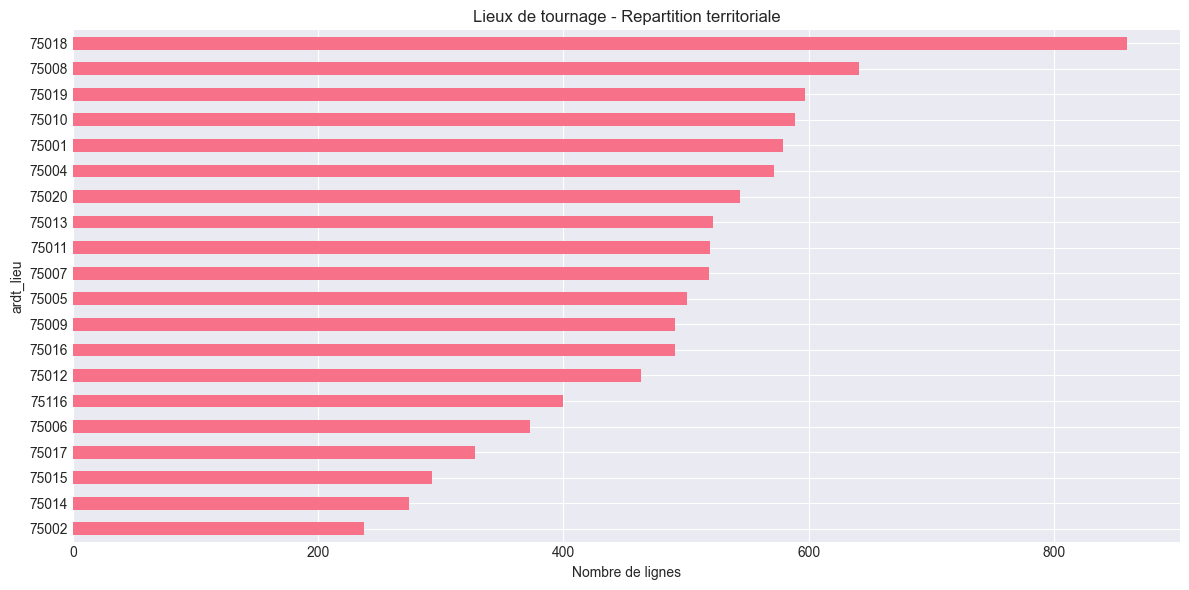

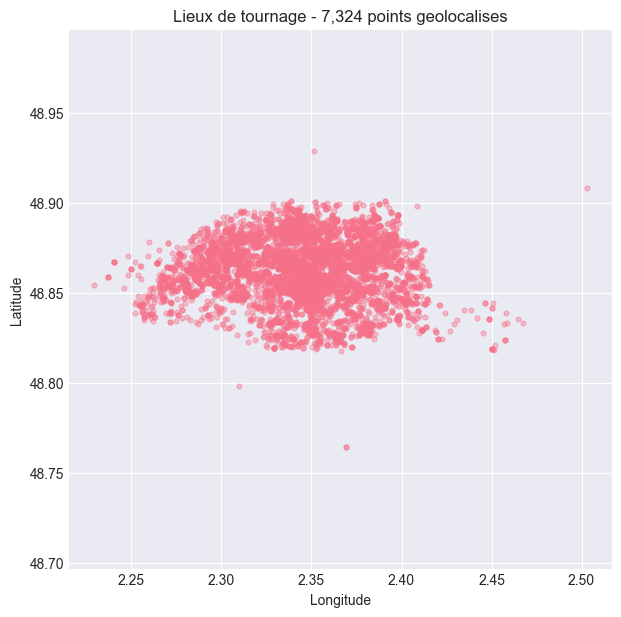

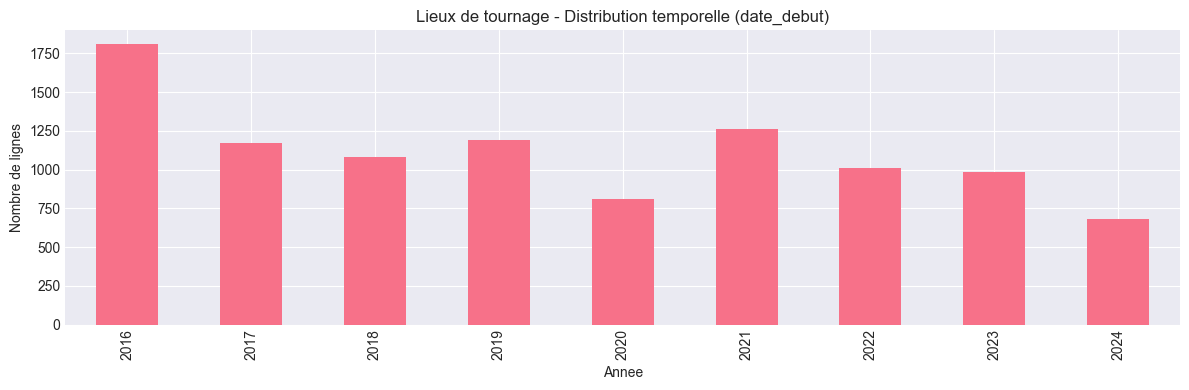


=== Analyse geo/temporelle: Que Faire a Paris ===


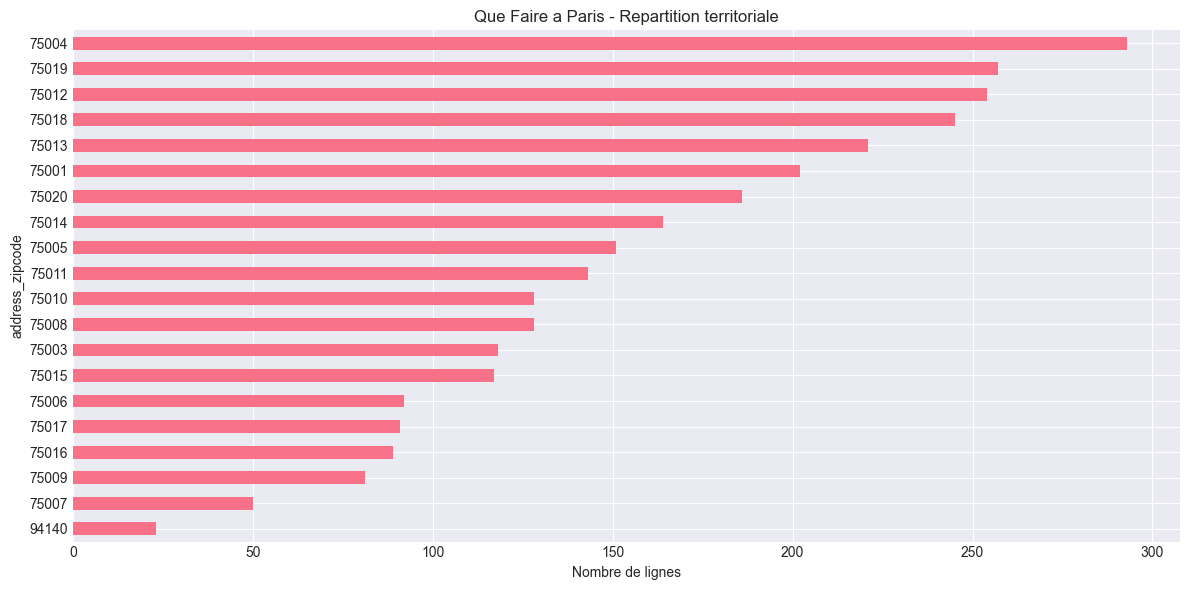

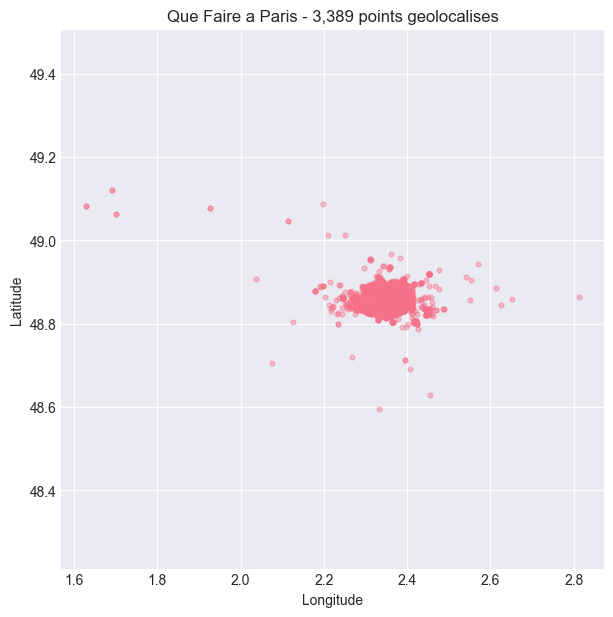

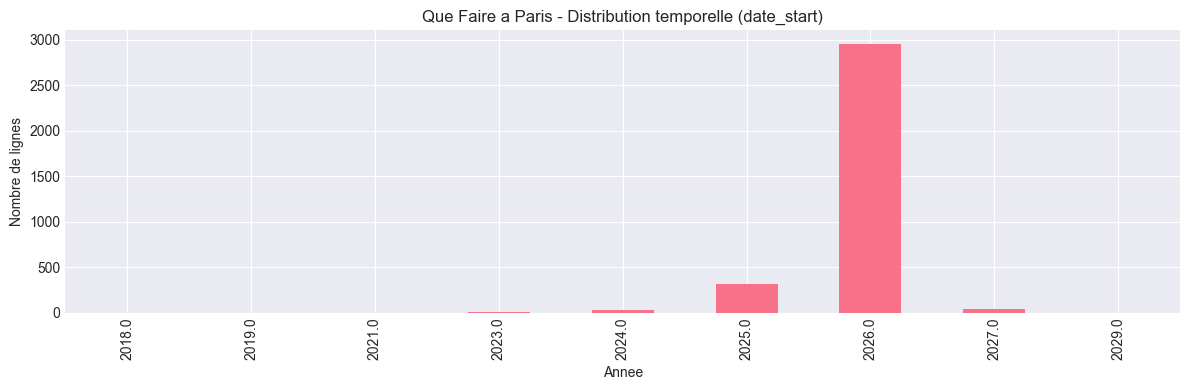


=== Analyse geo/temporelle: Terrasses autorisees ===


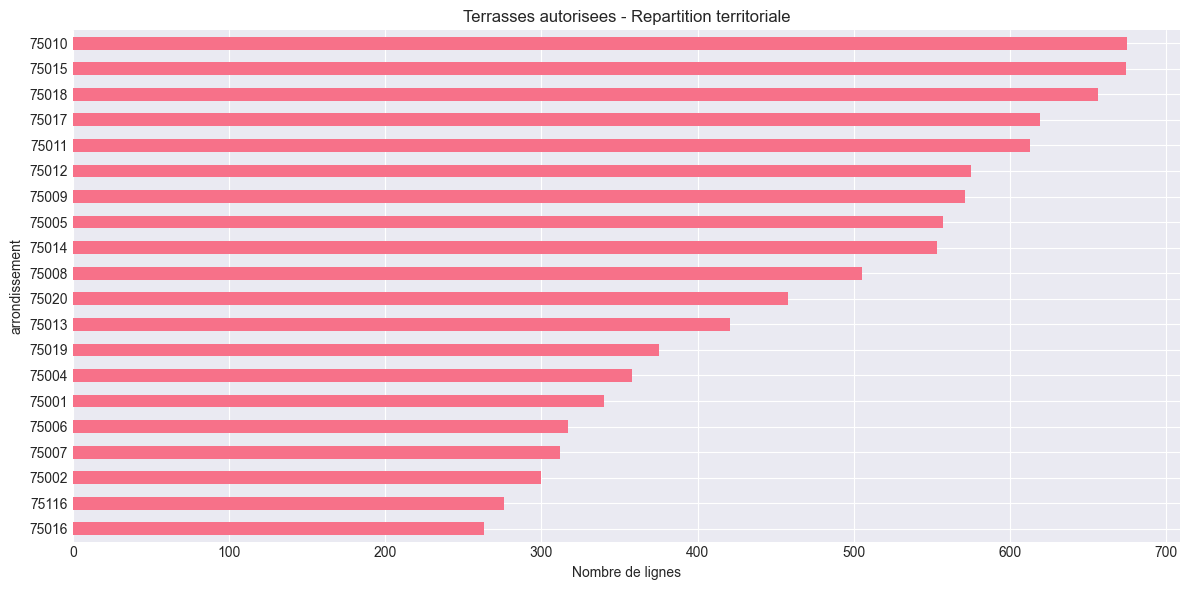

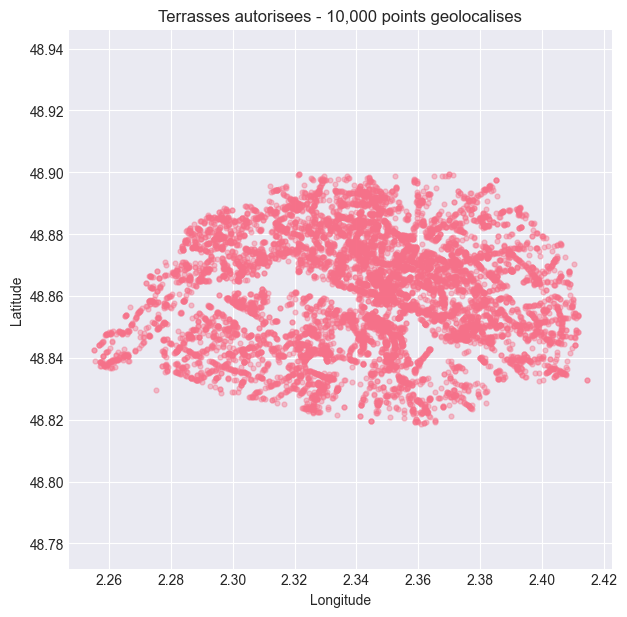


=== Analyse geo/temporelle: Salles de cinema IDF ===


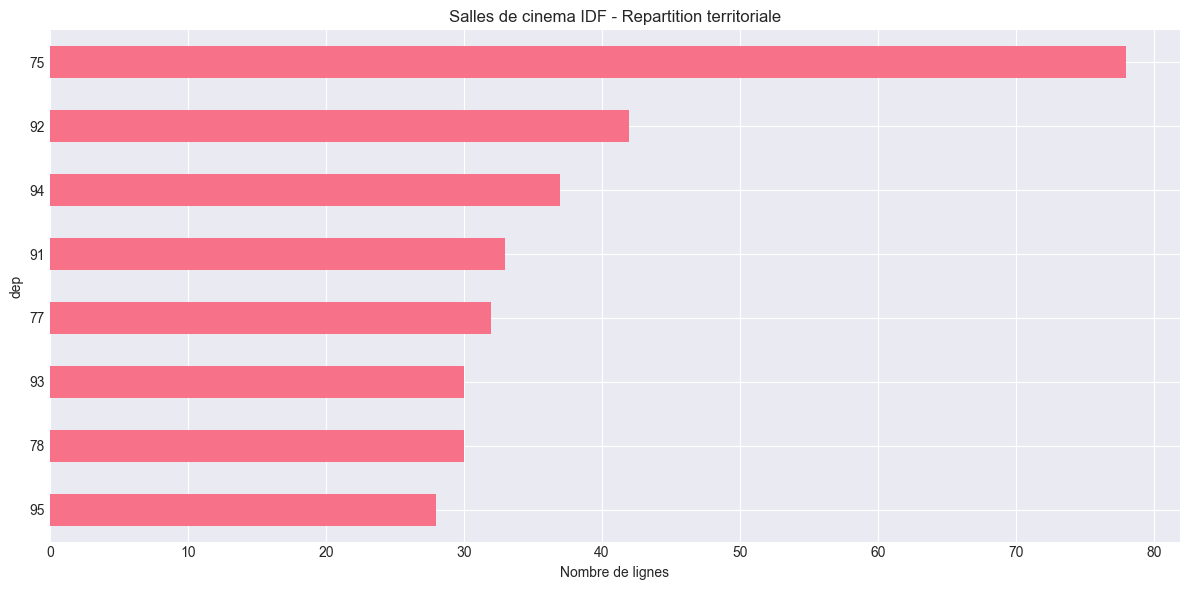

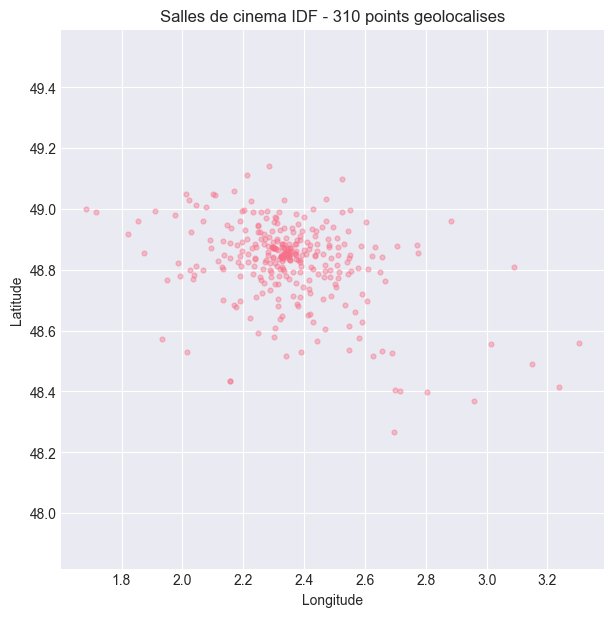


=== Analyse geo/temporelle: Musees franciliens ===


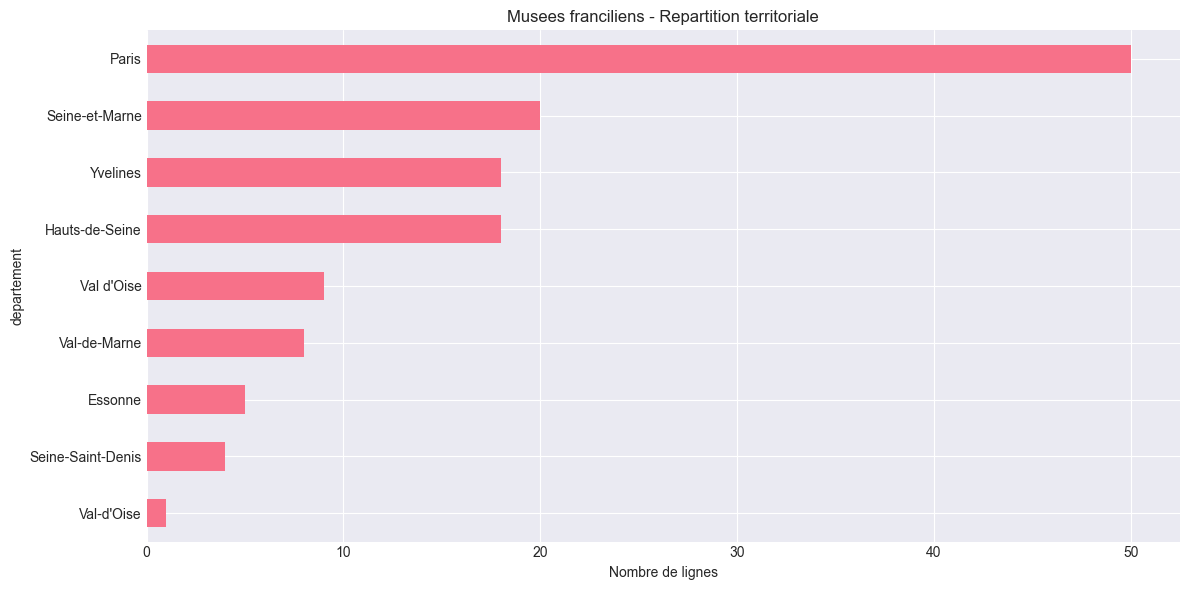

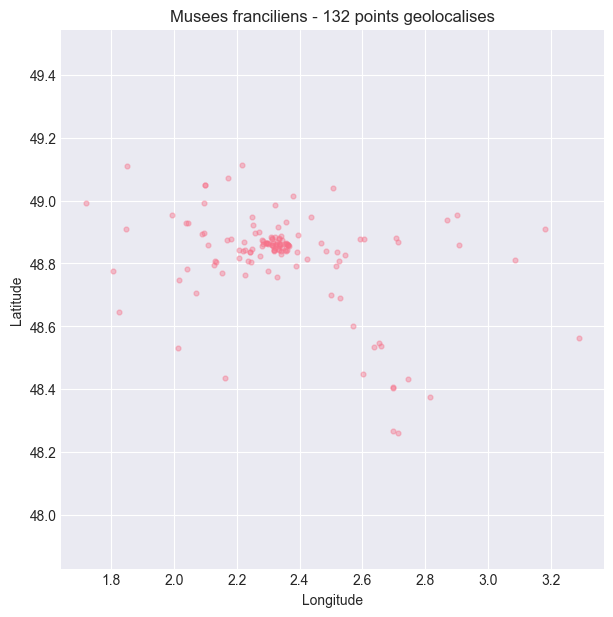

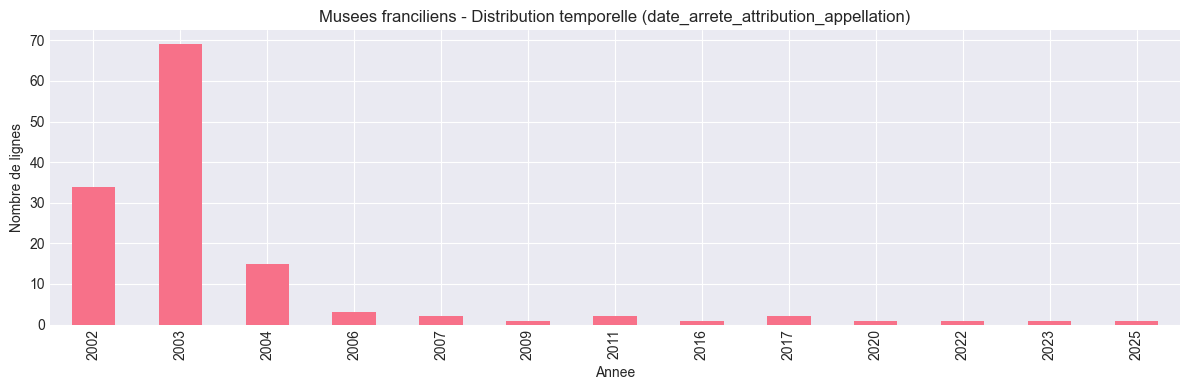


=== Analyse geo/temporelle: Associations parisiennes ===
Associations parisiennes: aucune coordonnee detectee


In [25]:
def find_first_column(df, candidates):
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    return None


def plot_top_counts(df, col, title, top=20):
    if col and col in df.columns and len(df) > 0:
        values = df[col].astype(str).replace({'nan': np.nan, 'None': np.nan}).dropna().value_counts().head(top).sort_values()
        if len(values) > 0:
            values.plot(kind='barh', figsize=(12, 6))
            plt.title(title)
            plt.xlabel('Nombre de lignes')
            plt.tight_layout()
            plt.show()


def plot_geo_points(df, lat_candidates, lon_candidates, point_candidates, title):
    if len(df) == 0:
        return
    lat_col = find_first_column(df, lat_candidates)
    lon_col = find_first_column(df, lon_candidates)
    coords = None
    if lat_col and lon_col:
        coords = df[[lat_col, lon_col]].rename(columns={lat_col: 'lat', lon_col: 'lon'})
    else:
        point_col = find_first_column(df, point_candidates)
        if point_col:
            extracted = df[point_col].astype(str).str.extract(r'(?P<lat>-?\d+(?:\.\d+)?)\s*,\s*(?P<lon>-?\d+(?:\.\d+)?)')
            coords = extracted.astype(float)
    if coords is None:
        print(f'{title}: aucune coordonnee detectee')
        return
    coords = coords.apply(pd.to_numeric, errors='coerce').dropna()
    coords = coords[(coords['lat'].between(40, 55)) & (coords['lon'].between(-10, 15))]
    if coords.empty:
        print(f'{title}: coordonnees non exploitables')
        return
    plt.figure(figsize=(7, 7))
    plt.scatter(coords['lon'], coords['lat'], s=12, alpha=0.4)
    plt.title(f'{title} - {len(coords):,} points geolocalises')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.axis('equal')
    plt.show()

for name, df in datasets.items():
    if len(df) == 0:
        continue
    print(f'\n=== Analyse geo/temporelle: {name} ===')
    territory_col = find_first_column(df, ['arrondissement', 'ardt_lieu', 'departement', 'dep', 'commune', 'code_postal', 'address_zipcode'])
    plot_top_counts(df, territory_col, f'{name} - Repartition territoriale')
    plot_geo_points(df, ['lat', 'latitude', 'coord_y'], ['lon', 'lng', 'longitude', 'coord_x'], ['geo_point_2d', 'geolocalisation', 'lat_lon', 'geo'], name)
    date_cols = [c for c in df.columns if any(token in c.lower() for token in ['date', 'annee', 'time_period', 'updated_at'])]
    if date_cols:
        date_col = date_cols[0]
        parsed = pd.to_datetime(df[date_col], errors='coerce')
        if parsed.notna().sum() > 0:
            parsed.dt.year.value_counts().sort_index().plot(kind='bar', figsize=(12, 4))
            plt.title(f'{name} - Distribution temporelle ({date_col})')
            plt.xlabel('Annee')
            plt.ylabel('Nombre de lignes')
            plt.tight_layout()
            plt.show()


## 7. Analyses Specifiques Culture

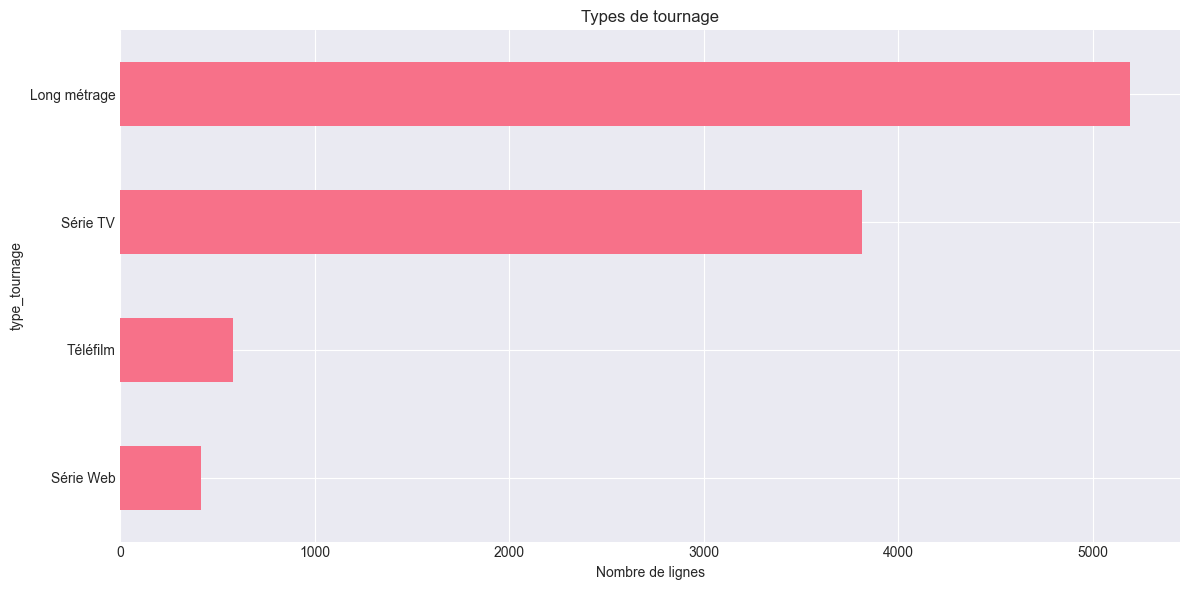

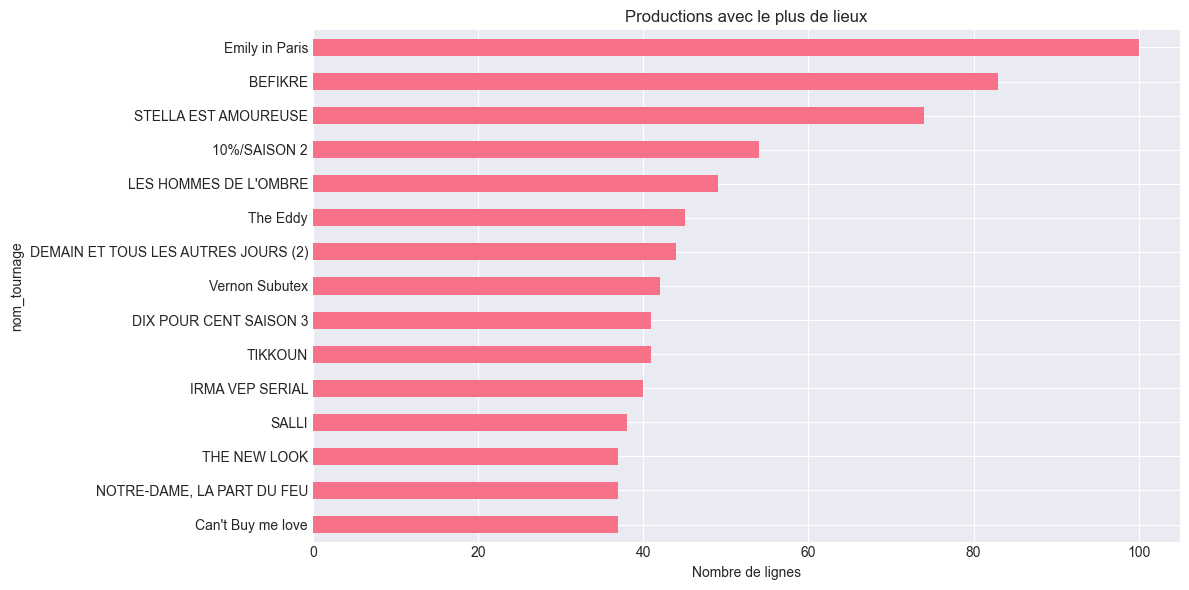

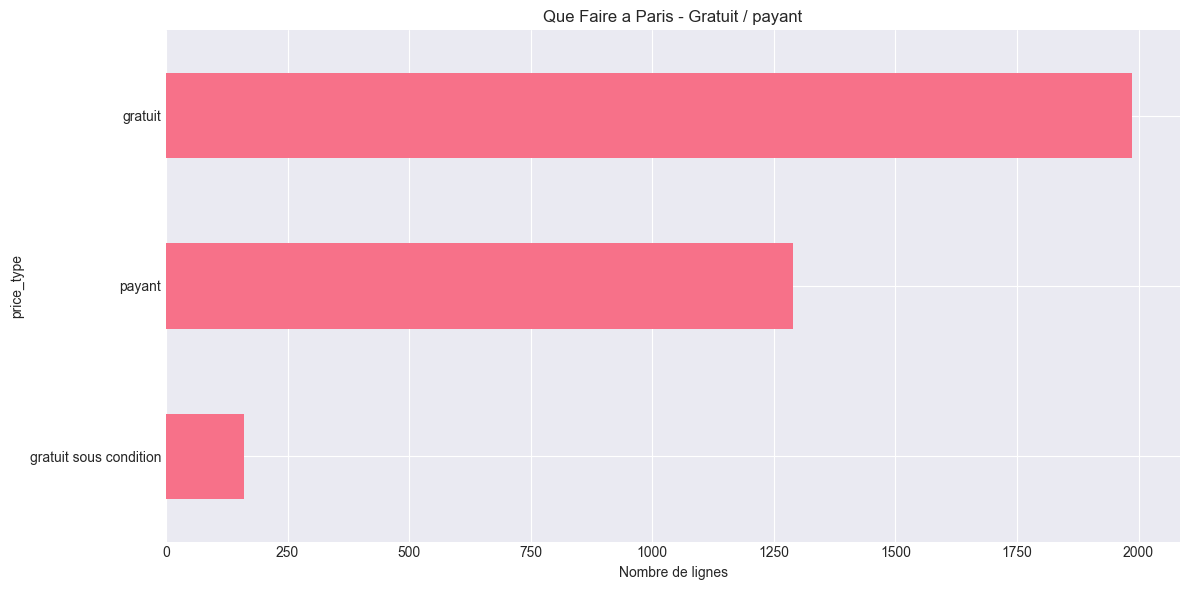

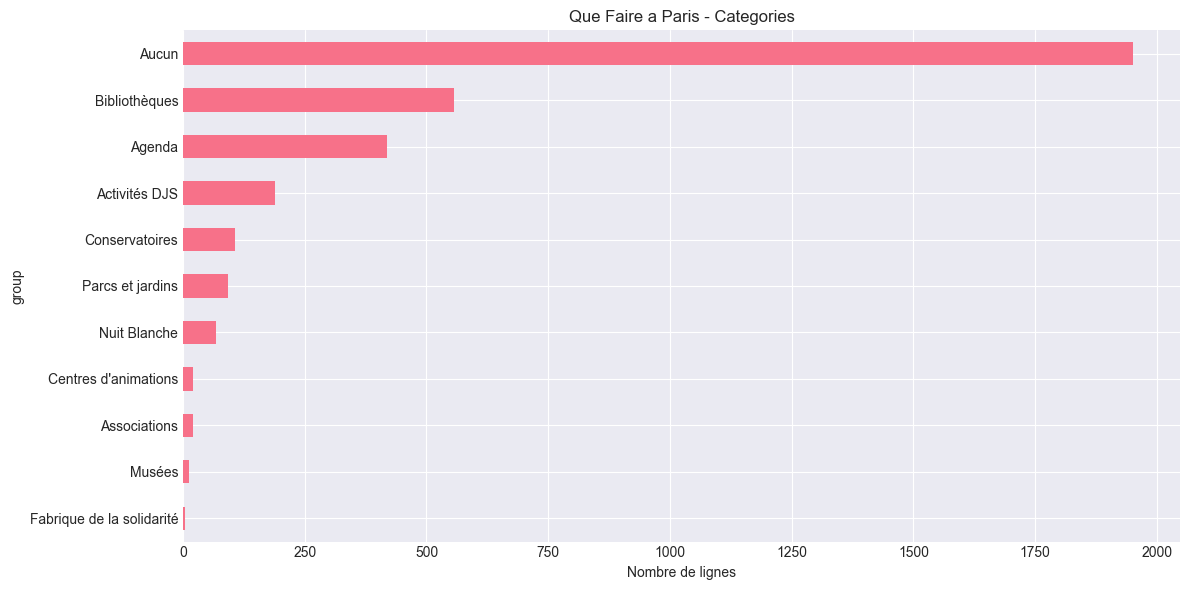

,nb_evenements_accessibles
pmr,1598.0
blind,606.0
deaf,589.0
sign_language,234.0
mental,589.0


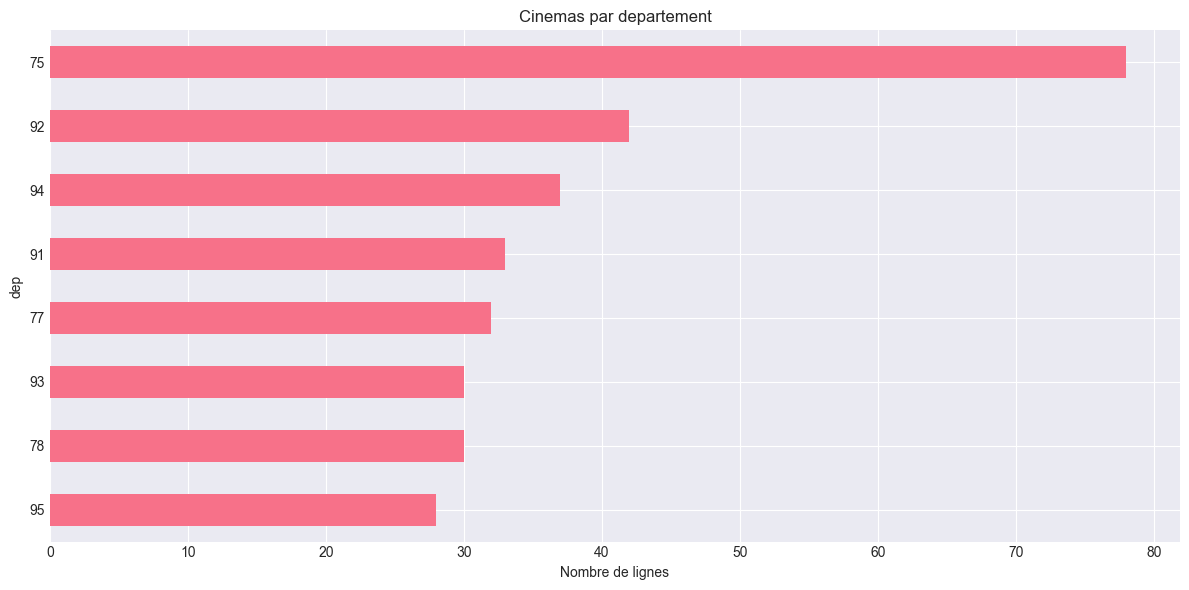

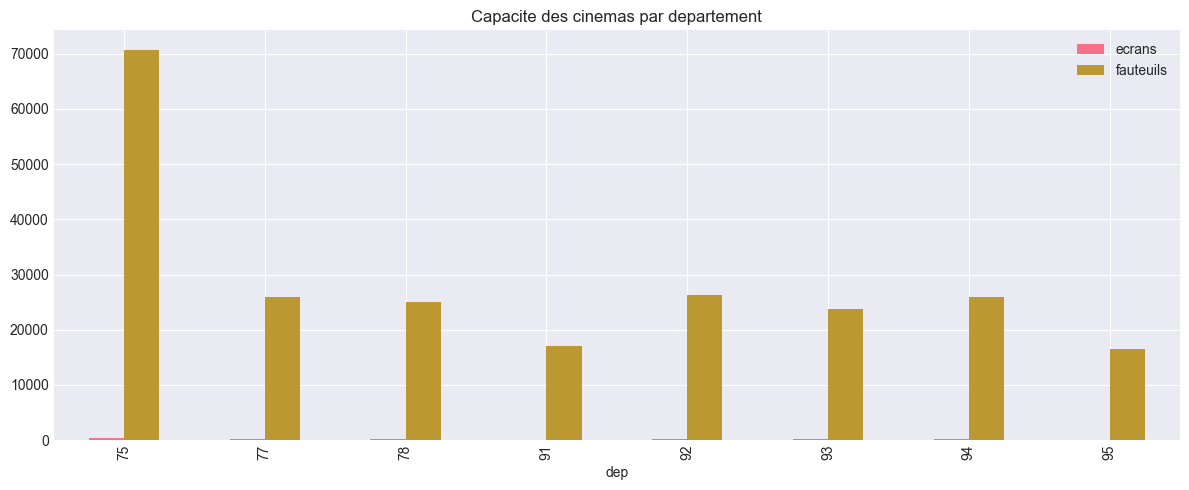

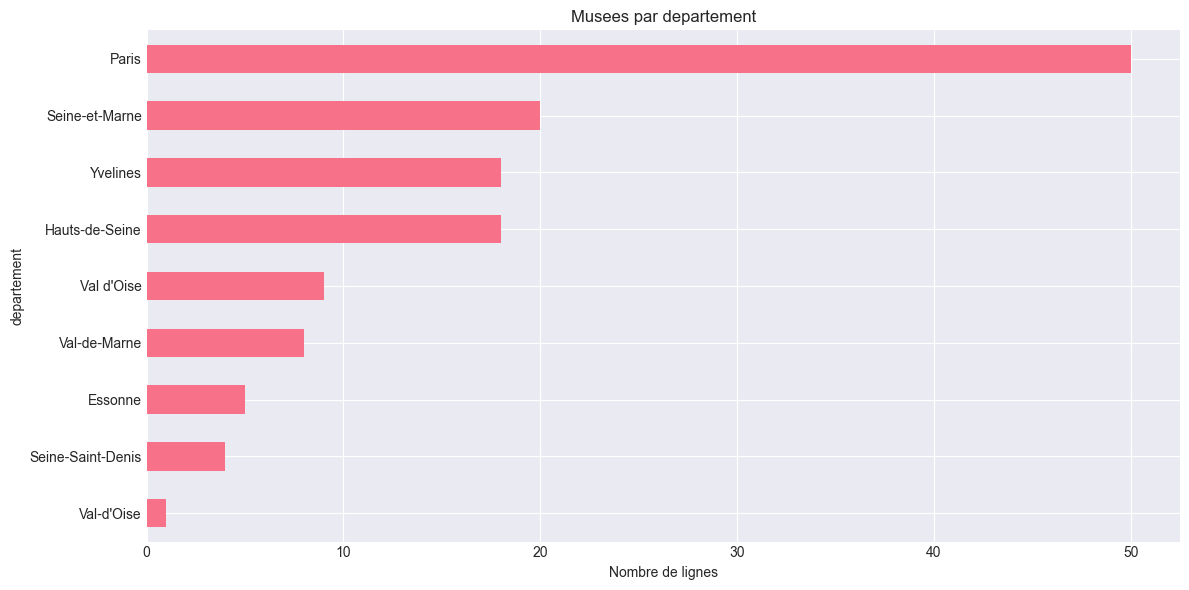

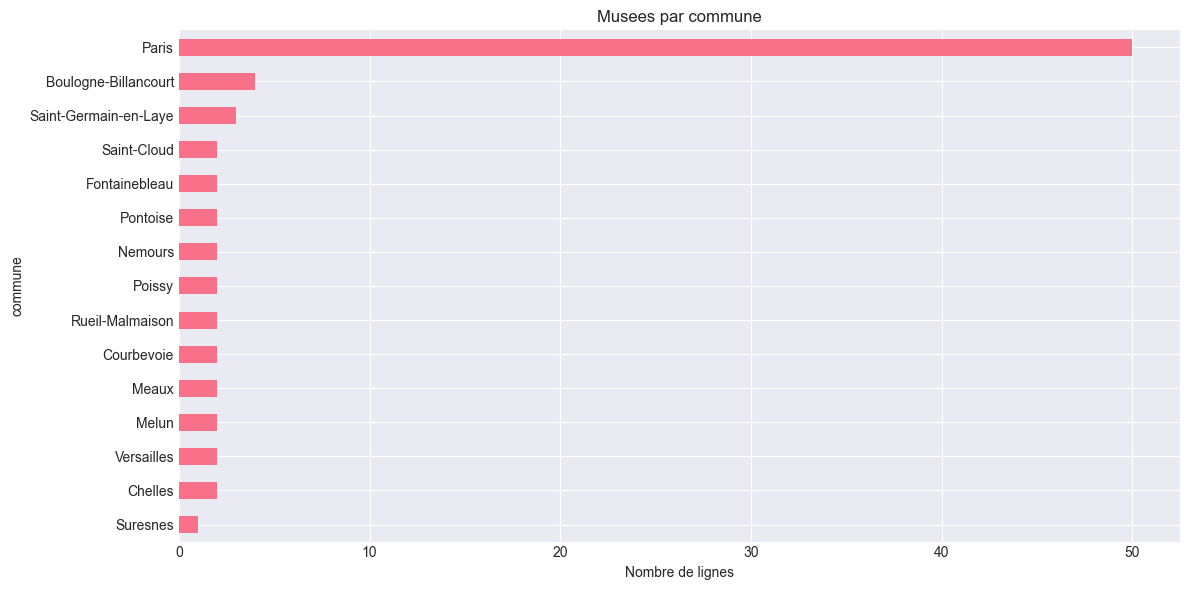

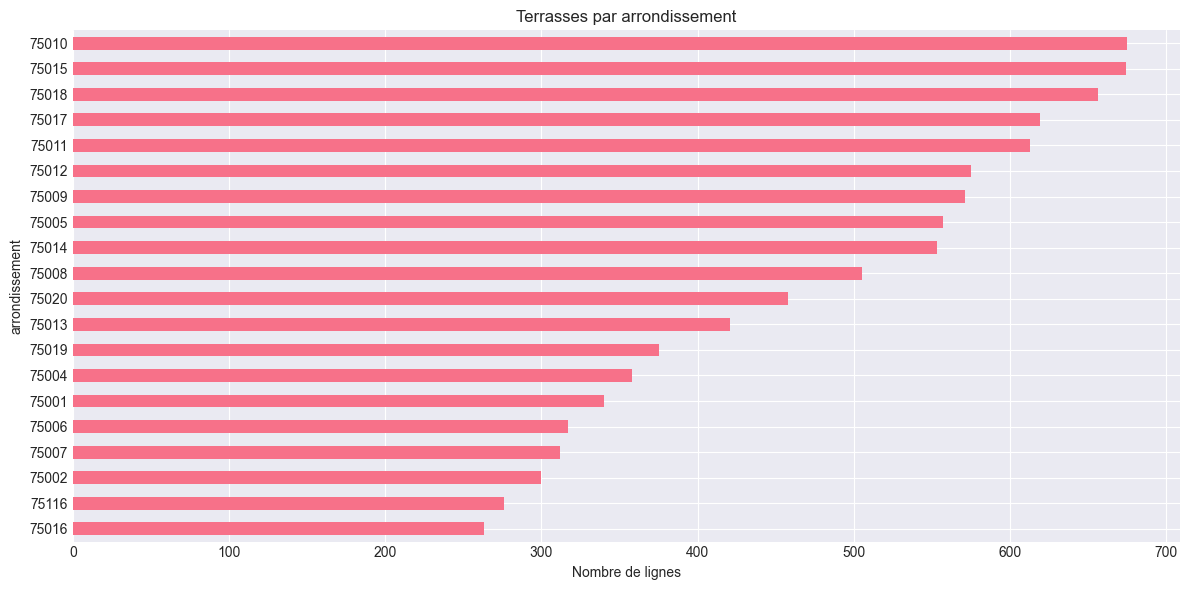

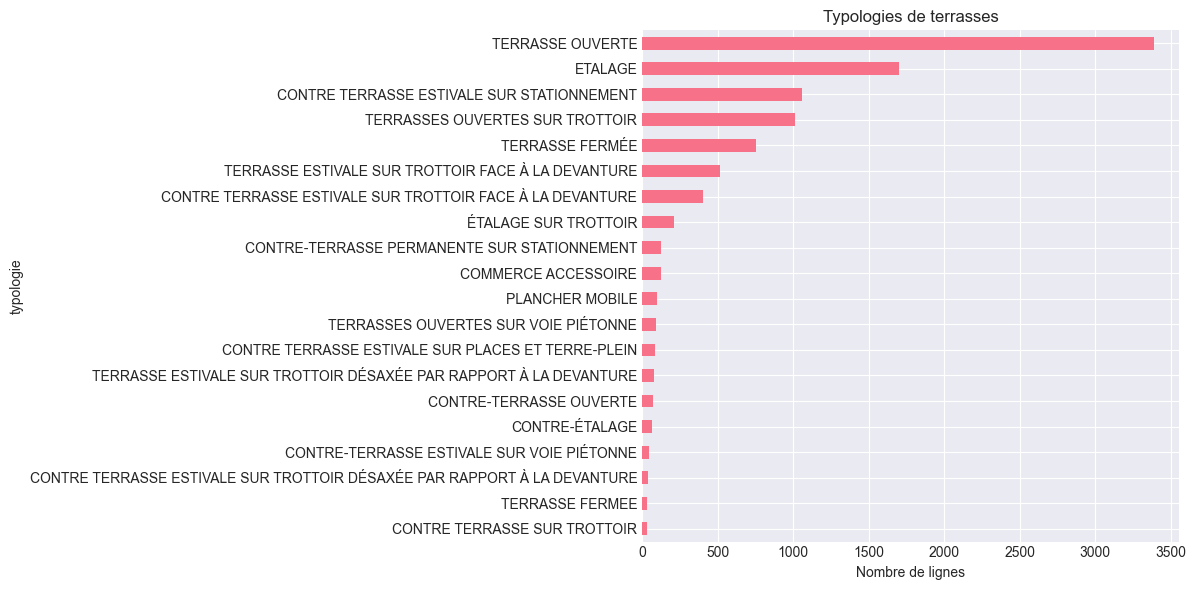

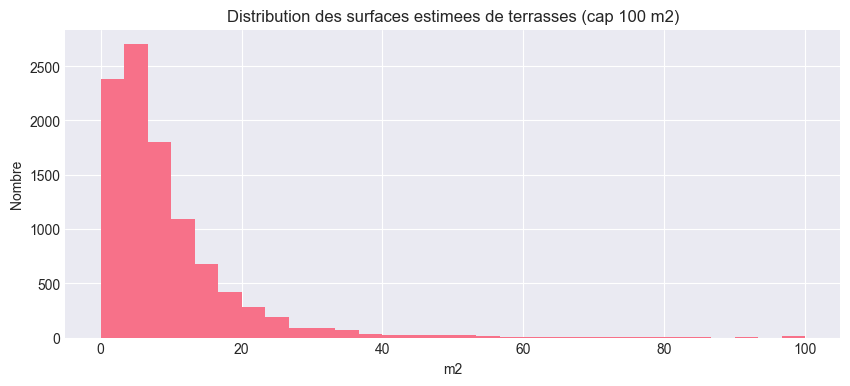

In [26]:
# Tournages
if len(df_tournages) > 0:
    type_col = find_first_column(df_tournages, ['type_tournage'])
    title_col = find_first_column(df_tournages, ['nom_tournage'])
    plot_top_counts(df_tournages, type_col, 'Types de tournage')
    plot_top_counts(df_tournages, title_col, 'Productions avec le plus de lieux', top=15)

# Evenements
if len(df_qfap) > 0:
    plot_top_counts(df_qfap, find_first_column(df_qfap, ['price_type']), 'Que Faire a Paris - Gratuit / payant')
    plot_top_counts(df_qfap, find_first_column(df_qfap, ['group']), 'Que Faire a Paris - Categories')
    access_cols = [c for c in ['pmr', 'blind', 'deaf', 'sign_language', 'mental'] if c in df_qfap.columns]
    if access_cols:
        display(df_qfap[access_cols].apply(pd.to_numeric, errors='coerce').sum().rename('nb_evenements_accessibles').to_frame())

# Cinemas
if len(df_cinemas) > 0:
    plot_top_counts(df_cinemas, find_first_column(df_cinemas, ['dep', 'departement']), 'Cinemas par departement')
    for col in ['ecrans', 'fauteuils', 'entrees_2020', 'entrees_2019']:
        if col in df_cinemas.columns:
            df_cinemas[col] = pd.to_numeric(df_cinemas[col], errors='coerce')
    cols = [c for c in ['ecrans', 'fauteuils'] if c in df_cinemas.columns]
    dep_col = find_first_column(df_cinemas, ['dep', 'departement'])
    if dep_col and cols:
        df_cinemas.groupby(dep_col)[cols].sum().plot(kind='bar', figsize=(12, 5))
        plt.title('Capacite des cinemas par departement')
        plt.tight_layout()
        plt.show()

# Musees
if len(df_musees) > 0:
    plot_top_counts(df_musees, find_first_column(df_musees, ['departement', 'dep']), 'Musees par departement')
    plot_top_counts(df_musees, find_first_column(df_musees, ['commune']), 'Musees par commune', top=15)

# Terrasses
if len(df_terrasses) > 0:
    plot_top_counts(df_terrasses, find_first_column(df_terrasses, ['arrondissement']), 'Terrasses par arrondissement')
    plot_top_counts(df_terrasses, find_first_column(df_terrasses, ['typologie']), 'Typologies de terrasses')
    if {'longueur', 'largeur'}.issubset(df_terrasses.columns):
        surface = pd.to_numeric(df_terrasses['longueur'], errors='coerce') * pd.to_numeric(df_terrasses['largeur'], errors='coerce')
        surface.dropna().clip(upper=100).hist(bins=30, figsize=(10, 4))
        plt.title('Distribution des surfaces estimees de terrasses (cap 100 m2)')
        plt.xlabel('m2')
        plt.ylabel('Nombre')
        plt.show()


## 8. Conclusions

### Resultats
- Les donnees culturelles sont chargees via API Ile de France et Paris OpenData.
- Le notebook ne depend plus uniquement des fichiers locaux du dossier `data/`, mais permet l'utilisation de sources externes sans devoir telecharger manuellement les fichiers.
- Les structures de donnees sont explorees pour comprendre les champs disponibles pour un nettoyage et une integration futurs.
- Les sources Paris/IDF sont recuperees via OpenDataSoft.
